<a href="https://colab.research.google.com/github/ayobami4/CPN-Project/blob/main/CPN_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ovarian cancer prediction using boosting technique

###Importating the libraries

In [1]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.metrics import classification_report, accuracy_score
from sklearn.feature_selection import VarianceThreshold

###Importing and downloading the dataset

In [2]:
path = kagglehub.dataset_download("saurabhshahane/predict-ovarian-cancer")
print("Path to dataset files:", path)

100%|██████████| 315k/315k [00:00<00:00, 475kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/saurabhshahane/predict-ovarian-cancer/versions/1


###Viewing what was downloaded

In [3]:
print(os.listdir(path))

['Supplementary data 4.xlsx', 'Supplementary data 1.xlsx', 'Supplementary data 3.xlsx', 'Supplementary data 5.xlsx', 'Supplementary data 2.xlsx']


###Updating 'filename.csv' with the actual name from the list above

In [4]:
ovarian_data = pd.read_excel(os.path.join(path, 'Supplementary data 1.xlsx'))

###Displaying the first few rows

In [5]:
ovarian_data.head()

,SUBJECT_ID,AFP,AG,Age,ALB,ALP,ALT,AST,BASO#,BASO%,...,NEU,PCT,PDW,PHOS,PLT,RBC,RDW,TBIL,TP,UA
0,1,3.58\t,19.36,47,45.4,56.0,11.0,24.0,0.01,0.30,...,76.2,0.09,13.4,1.46,74,2.64,13.7,5.5,73.9,396.4
1,2,34.24\t,23.98,61,39.9,95.0,9.0,13.0,0.02,0.30,...,76.5,0.30,11.2,1.09,304,4.89,12.7,6.8,72.0,119.2
2,3,1.50\t,18.40,39,45.4,77.0,9.0,18.0,0.03,0.60,...,69.7,0.13,15.2,0.97,112,4.62,12.0,14.8,77.9,209.2
3,4,2.75,16.60,45,39.2,26.0,16.0,17.0,0.05,0.74,...,65.5,0.25,17.4,1.25,339,4.01,14.6,10.9,66.1,215.6
4,5,2.36,19.97,45,35.0,47.0,21.0,27.0,0.01,0.10,...,59.5,0.28,11.9,0.94,272,4.40,13.4,5.3,66.5,206.0


###Checking the information of the joined data using info, and checking for inconsistencies such as null, missing, etc.

In [6]:
ovarian_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 51 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   SUBJECT_ID  349 non-null    int64  
 1   AFP         327 non-null    object 
 2   AG          348 non-null    float64
 3   Age         349 non-null    int64  
 4   ALB         339 non-null    float64
 5   ALP         339 non-null    float64
 6   ALT         339 non-null    float64
 7   AST         339 non-null    float64
 8   BASO#       349 non-null    float64
 9   BASO%       349 non-null    float64
 10  BUN         349 non-null    float64
 11  Ca          349 non-null    float64
 12  CA125       332 non-null    object 
 13  CA19-9      325 non-null    object 
 14  CA72-4      109 non-null    float64
 15  CEA         327 non-null    float64
 16  CL          349 non-null    float64
 17  CO2CP       348 non-null    float64
 18  CREA        349 non-null    float64
 19  TYPE        349 non-null    i

###Checking for missing values and summing up all null using isnull and sum

In [7]:
ovarian_data.isnull().sum()

,0
SUBJECT_ID,0
AFP,22
AG,1
Age,0
ALB,10
ALP,10
ALT,10
AST,10
BASO#,0
BASO%,0


###Treating the missing values of each columns using row mean

In [8]:
ovarian_data['AG'].fillna(ovarian_data['AG'].mean(), inplace=True)
ovarian_data['ALB'].fillna(ovarian_data['ALB'].mean(), inplace=True)
ovarian_data['ALP'].fillna(ovarian_data['ALP'].mean(), inplace=True)
ovarian_data['ALT'].fillna(ovarian_data['ALT'].mean(), inplace=True)
ovarian_data['AST'].fillna(ovarian_data['AST'].mean(), inplace=True)
ovarian_data['CEA'].fillna(ovarian_data['CEA'].mean(), inplace=True)
ovarian_data['CO2CP'].fillna(ovarian_data['CO2CP'].mean(), inplace=True)
ovarian_data['DBIL'].fillna(ovarian_data['DBIL'].mean(), inplace=True)
ovarian_data['GGT'].fillna(ovarian_data['GGT'].mean(), inplace=True)
ovarian_data['GLO'].fillna(ovarian_data['GLO'].mean(), inplace=True)
ovarian_data['HE4'].fillna(ovarian_data['HE4'].mean(), inplace=True)
ovarian_data['IBIL'].fillna(ovarian_data['IBIL'].mean(), inplace=True)
ovarian_data['NEU'].fillna(ovarian_data['NEU'].mean(), inplace=True)
ovarian_data['PCT'].fillna(ovarian_data['PCT'].mean(), inplace=True)
ovarian_data['PDW'].fillna(ovarian_data['PDW'].mean(), inplace=True)
ovarian_data['TBIL'].fillna(ovarian_data['TBIL'].mean(), inplace=True)
ovarian_data['TP'].fillna(ovarian_data['TP'].mean(), inplace=True)
ovarian_data['CA72-4'].fillna(ovarian_data['CA72-4'].mean(), inplace=True)
ovarian_data['MPV'].fillna(ovarian_data['MPV'].mean(), inplace=True)

/tmp/ipykernel_5899/3006931551.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ovarian_data['AG'].fillna(ovarian_data['AG'].mean(), inplace=True)
/tmp/ipykernel_5899/3006931551.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, in

###Dropping not too relevant columns

In [9]:
ovarian_data.drop(['AFP', 'CA19-9', 'CA125', 'SUBJECT_ID'], axis=1, inplace=True)

###Checking the size of the data after cleaning it

In [10]:
ovarian_data.shape

(349, 47)

###Visualizing the distribution of the TYPES using seaborn library with countplot method

<Axes: xlabel='TYPE', ylabel='count'>

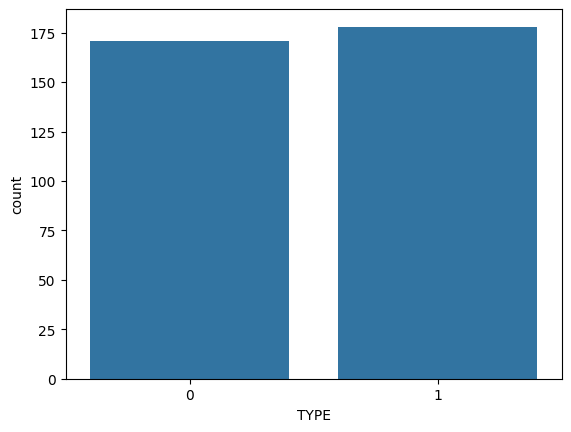

In [11]:
sns.countplot(x = ovarian_data['TYPE'])

###Data is into independent variables(user inputs) and dependent variable(results/output)

In [12]:
x = ovarian_data.drop('TYPE', axis=1)
y = ovarian_data['TYPE']

###Feature Selection using Variance threshold estimator

In [13]:
var_thres= VarianceThreshold(threshold=0)
var_thres.fit(x)
var_thres.get_support()

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True])

###The independent variables and dependent variables are split into training and testing set

In [14]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)

###An instance of gradient boosting

In [15]:
gbc_model=GradientBoostingClassifier(learning_rate=1, max_depth=2, n_estimators=200,
                          random_state=1)

###Training the gradient boosting model

In [16]:
gbc_model.fit(x_train, y_train)

GradientBoostingClassifier(learning_rate=1, max_depth=2, n_estimators=200,
                           random_state=1)

###Making prediction with the trained model

In [17]:
y_pred = gbc_model.predict(x_test)

###Evaluatig with accuracy_score

In [18]:
gbc_score = accuracy_score(y_pred, y_test)
print(gbc_score)

0.8857142857142857


###Displaying the model correct and incorrect prediction

In [19]:
test_data = pd.concat([x_test, y_test], axis=1)
test_data['Prediction'] = y_pred
correct_predictions = test_data[test_data['TYPE'] == test_data['Prediction']]
incorrect_predictions = test_data[test_data['TYPE'] != test_data['Prediction']]
print("Correct Predictions:")
correct_predictions
print("Incorrect Predictions:")
incorrect_predictions

Correct Predictions:
Incorrect Predictions:


,AG,Age,ALB,ALP,ALT,AST,BASO#,BASO%,BUN,Ca,...,PDW,PHOS,PLT,RBC,RDW,TBIL,TP,UA,TYPE,Prediction
216,23.83,64,41.5,112.0,38.0,20.0,0.04,0.50,5.58,2.64,...,19.40,1.26,209,5.00,13.00,10.5,77.1,226.3,1,0
186,20.59,47,39.2,79.0,18.0,12.0,0.06,0.79,2.45,2.20,...,16.70,0.89,345,4.20,13.40,8.2,67.3,213.5,1,0
179,25.02,27,50.9,84.0,16.0,15.0,0.01,0.16,3.80,2.42,...,16.37,0.92,193,4.31,12.58,9.2,80.0,274.6,1,0
198,18.90,36,38.5,65.0,13.0,14.0,0.02,0.29,3.50,2.34,...,16.58,1.08,340,3.95,16.27,4.4,79.0,205.0,1,0
205,20.74,36,39.5,101.0,21.0,16.0,0.00,0.20,2.23,2.50,...,16.60,0.96,266,4.52,12.50,8.5,66.6,211.7,1,0
126,20.43,61,42.6,111.0,18.0,11.0,0.04,0.74,4.82,2.46,...,17.50,1.18,188,4.39,12.90,11.6,75.8,230.1,0,1
161,17.03,51,33.1,105.0,28.0,10.0,0.04,0.32,3.55,2.29,...,17.00,0.85,223,3.78,13.50,5.3,63.9,102.3,1,0
128,24.48,23,39.0,49.0,7.0,11.0,0.02,0.40,3.03,2.50,...,11.40,1.12,204,4.24,13.10,5.7,78.9,206.4,0,1
